In [12]:
import pandas as pd

df = pd.read_csv("../data/resume_data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (169, 2)


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [13]:
df.columns

Index(['Category', 'Resume'], dtype='str')

In [14]:
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['cleaned_resume'] = df['Resume'].apply(preprocess)

df

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Category,Resume,cleaned_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,skills programming languages python pandas num...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education details may may uitrgpvdata scientis...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",areas interest deep learning control system de...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skills â r â python â sap hana â tableau â sap...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education details mca ymcaust faridabad haryan...
...,...,...,...
164,Testing,Computer Skills: â¢ Proficient in MS office (...,computer skills â proficient ms office word ba...
165,Testing,â Willingness to accept the challenges. â ...,â willingness accept challenges â positive thi...
166,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne...",personal skills â quick learner â eagerness le...
167,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...,computer skills software knowledge mspower poi...


In [15]:
import re
import unicodedata
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))


def preprocess(text):

    text = str(text)

    # Fix encoding
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("utf-8", "ignore")

    # Lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
df['cleaned_resume'] = df['Resume'].apply(preprocess)
df[['Resume','cleaned_resume']].head()

,Resume,cleaned_resume
0,Skills * Programming Languages: Python (pandas...,skills programming languages python pandas num...
1,Education Details \r\nMay 2013 to May 2017 B.E...,education details may may uitrgpvdata scientis...
2,"Areas of Interest Deep Learning, Control Syste...",areas interest deep learning control system de...
3,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skills r python sap hana tableau sap hana sql ...
4,"Education Details \r\n MCA YMCAUST, Faridab...",education details mca ymcaust faridabad haryan...


In [17]:
# ================================
# Dataset Cleaning Verification
# ================================

import re

print("Checking cleaned dataset...\n")

# 1. Compare original and cleaned resume
index = 0

print("Original Resume (first 500 characters):\n")
print(df['Resume'][index][:500])

print("\nCleaned Resume (first 500 characters):\n")
print(df['cleaned_resume'][index][:500])
print("\n---------------------------------------\n")

# 2. Check if numbers still exist
numbers_left = df['cleaned_resume'].apply(lambda x: bool(re.search(r'\d', x))).sum()
print("Number of resumes containing digits:", numbers_left)

# 3. Check if special characters still exist
special_chars_left = df['cleaned_resume'].apply(lambda x: bool(re.search(r'[^\w\s]', x))).sum()
print("Number of resumes containing special characters:", special_chars_left)

# 4. Check if all text is lowercase
all_lowercase = df['cleaned_resume'].apply(lambda x: x.islower()).all()
print("All resumes are lowercase:", all_lowercase)

# 5. Check for empty resumes
empty_rows = df['cleaned_resume'].apply(lambda x: len(x.strip()) == 0).sum()
print("Number of empty cleaned resumes:", empty_rows)

print("\nVerification completed.")

Checking cleaned dataset...

Original Resume (first 500 characters):

Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib

Cleaned Resume (first 500 characters):

skills programming languages python pandas numpy scipy scikitlearn matplotlib sql java javascriptjquery machine learning regression svm naa bayes knn random forest decision trees boosting techniques cluster analysis word embedding sentiment analysis natural language processing dimensionality reduction topic modelling lda nmf pca neural nets database visualizations mysql sqlserver cassa

In [18]:
df

,Category,Resume,cleaned_resume
0,Data Science,Skills * Programming Languages: Python (pandas...,skills programming languages python pandas num...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education details may may uitrgpvdata scientis...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",areas interest deep learning control system de...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skills r python sap hana tableau sap hana sql ...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education details mca ymcaust faridabad haryan...
...,...,...,...
164,Testing,Computer Skills: â¢ Proficient in MS office (...,computer skills proficient ms office word basi...
165,Testing,â Willingness to accept the challenges. â ...,willingness accept challenges positive thinkin...
166,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne...",personal skills quick learner eagerness learn ...
167,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...,computer skills software knowledge mspower poi...


In [19]:
#for saving the cleaned dataset
df.to_csv("cleaned_resume_dataset.csv", index=False)

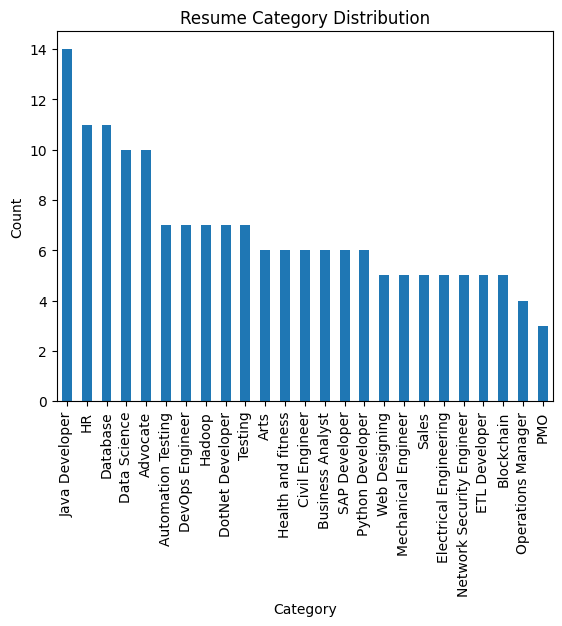

In [20]:
import matplotlib.pyplot as plt

# Count resume categories (if column exists)
if 'Category' in df.columns:
    category_counts = df['Category'].value_counts()

    plt.figure()
    category_counts.plot(kind='bar')
    plt.title("Resume Category Distribution")
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.show()

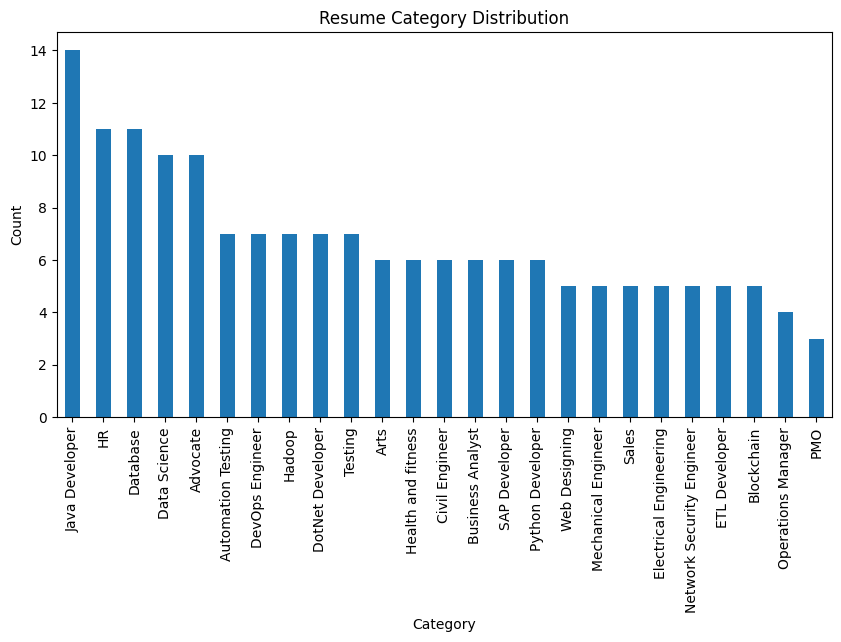

In [21]:
import matplotlib.pyplot as plt

category_counts = df['Category'].value_counts()

plt.figure(figsize=(10,5))
category_counts.plot(kind='bar')

plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

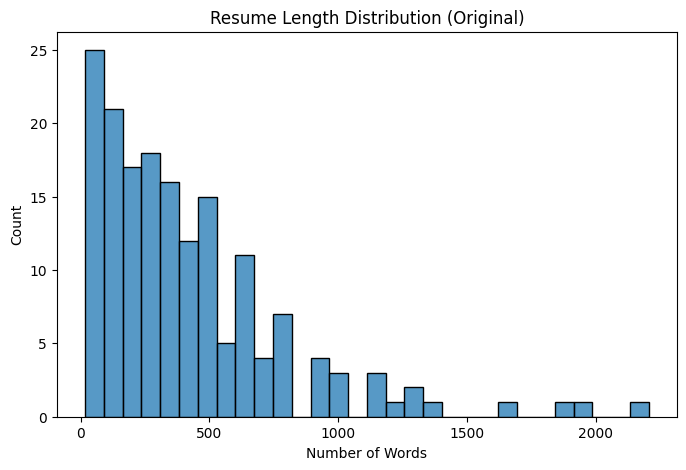

In [24]:
# Resume Length Distribution
df['resume_length'] = df['Resume'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df['resume_length'], bins=30)
plt.title("Resume Length Distribution (Original)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

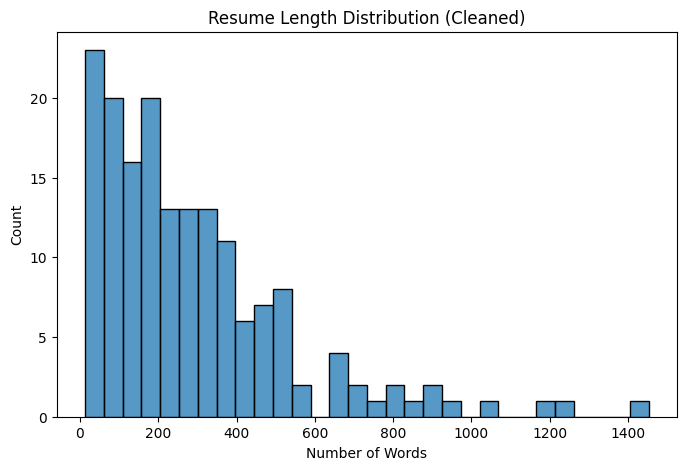

In [28]:
# Resume Length After Cleaning
df['cleaned_length'] = df['cleaned_resume'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df['cleaned_length'], bins=30)
plt.title("Resume Length Distribution (Cleaned)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

In [ ]:
from collections import Counter

all_words = " ".join(df['cleaned_resume']).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Most Common Words")
plt.show()

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

tfidf_matrix = tfidf.fit_transform(df['cleaned_resume'])

print("TF-IDF Matrix Shape:", tfidf_matrix.shape)

TF-IDF Matrix Shape: (169, 5000)


Top 5 Matching Resumes:

       Category  similarity_score
8  Data Science          0.376575
7  Data Science          0.352026
6  Data Science          0.268020
9  Data Science          0.206949
0  Data Science          0.160388


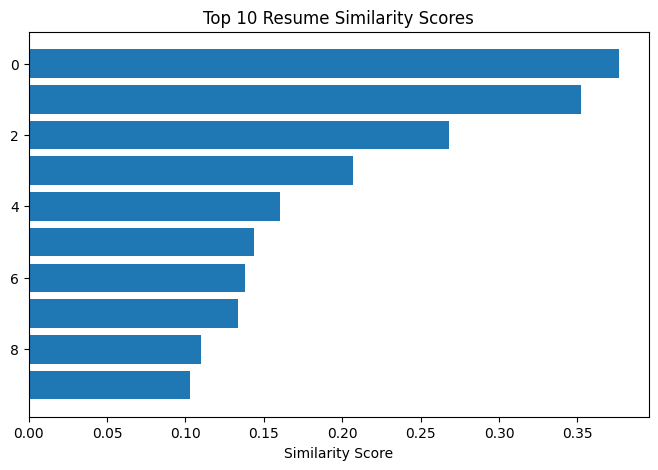

In [27]:
# Cosine Similarity + Resume Ranking
# =====================================
# DAY 4 — Resume Ranking Using Cosine Similarity
# =====================================

# Import required libraries
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

# -------------------------------------
# Step 1 — Create Job Description
# -------------------------------------

job_description = """
Looking for a Data Scientist with strong knowledge in Python,
Machine Learning, Data Analysis, Pandas, NumPy, and Scikit-learn.
Experience in NLP and deep learning is a plus.
"""

# -------------------------------------
# Step 2 — Clean the Job Description
# -------------------------------------

cleaned_jd = preprocess(job_description)

# -------------------------------------
# Step 3 — Convert JD to TF-IDF Vector
# -------------------------------------

jd_vector = tfidf.transform([cleaned_jd])

# -------------------------------------
# Step 4 — Compute Cosine Similarity
# -------------------------------------

similarity_scores = cosine_similarity(jd_vector, tfidf_matrix)

# -------------------------------------
# Step 5 — Add Similarity Score to DataFrame
# -------------------------------------

df['similarity_score'] = similarity_scores[0]

# -------------------------------------
# Step 6 — Sort Resumes by Score
# -------------------------------------

df_sorted = df.sort_values(by='similarity_score', ascending=False)

print("Top 5 Matching Resumes:\n")
print(df_sorted[['Category', 'similarity_score']].head())

# -------------------------------------
# Step 7 — Plot Top 10 Similarity Scores
# -------------------------------------

top10 = df_sorted.head(10)

plt.figure(figsize=(8,5))
plt.barh(range(10), top10['similarity_score'])
plt.gca().invert_yaxis()
plt.title("Top 10 Resume Similarity Scores")
plt.xlabel("Similarity Score")
plt.show()

In [29]:
# Enter Job Description
job_description = """
Looking for a Data Scientist with skills in Python, Machine Learning,
Deep Learning, NLP, and Data Analysis.
"""

# Clean JD
cleaned_jd = preprocess(job_description)

# Convert JD to vector
jd_vector = tfidf.transform([cleaned_jd])

# Similarity
similarity_scores = cosine_similarity(jd_vector, tfidf_matrix)

# Top 5 matches
top_indices = similarity_scores[0].argsort()[-5:][::-1]

# Show results
df.iloc[top_indices][['Category', 'Resume']]

,Category,Resume
7,Data Science,Education Details \r\n B.Tech Rayat and Bahr...
8,Data Science,Personal Skills â¢ Ability to quickly grasp t...
6,Data Science,Skills â¢ Python â¢ Tableau â¢ Data Visuali...
9,Data Science,Expertise â Data and Quantitative Analysis â...
137,Database,"TECHNICAL SKILLS â¢ SQL â¢ Oracle v10, v11, ..."


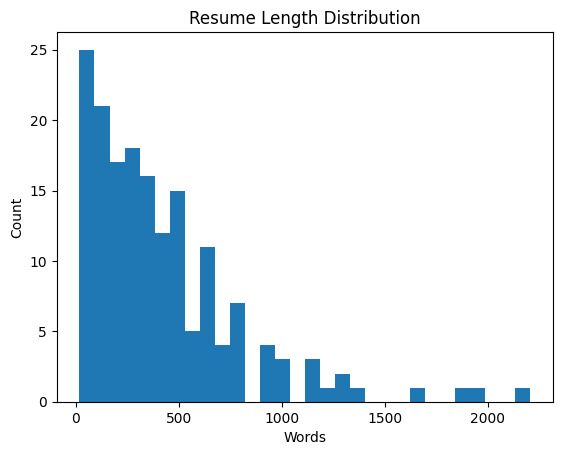

In [30]:
import matplotlib.pyplot as plt

df['resume_length'] = df['Resume'].apply(lambda x: len(str(x).split()))

plt.figure()
plt.hist(df['resume_length'], bins=30)
plt.title("Resume Length Distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()


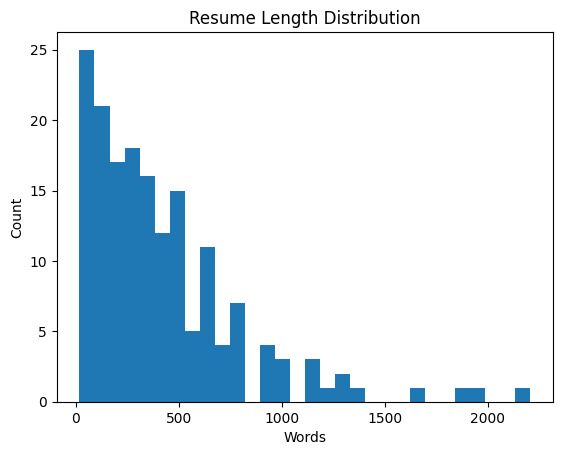

In [31]:
import matplotlib.pyplot as plt

df['resume_length'] = df['Resume'].apply(lambda x: len(str(x).split()))

plt.figure()
plt.hist(df['resume_length'], bins=30)
plt.title("Resume Length Distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

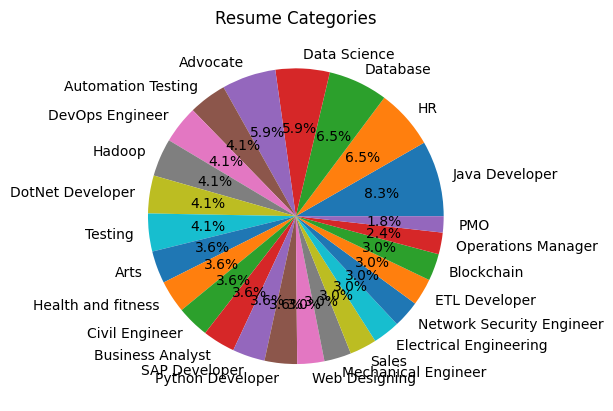

In [32]:
df['Category'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Resume Categories")
plt.ylabel("")
plt.show()